# Introduction
Cervical intraepithelial neoplasia (CIN) progresses along a measurable disease pathway, making early, individualized risk prediction essential for timely intervention. This project aims to support personalized risk-to-timeline modeling by evaluating traditional machine learning algorithms on the UCI cervical cancer risk-factor dataset. 
The Cervical Cancer Risk Dataset from UCI is the one that has been used in this project. An initial benchmark using nine models; KNN, three SVM kernels, GaussianNB, Gradient Boosting, MLP, Decision Trees, and Easy Ensemble, was conducted with a single train–test split to compare baseline performance under severe class imbalance. 
To ensure more reliable estimates of generalizability, a 3-fold cross-validation was then applied across all models. Together, these steps provide a foundation for developing a more robust and clinically meaningful timeline-based CIN risk prediction framework.

## Reading the data

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\Lusubilo Nyondo\OneDrive\Documents\MTU Fall 25 Semester\SAT 5141\Research project\cervical+cancer+risk+factors.zip")
df.head(5)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [2]:
df.shape

(858, 36)

In [3]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [4]:
df.describe()

,Age,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,0.087413,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,0.302545,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

## Checking data for Missing values per columns

In [6]:
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

### Missing values percentages per column

In [7]:
null_percentages = df.isnull().sum() / len(df)
print("Percentage of null values per column:")
print(null_percentages.sort_values(ascending=False))

Percentage of null values per column:
STDs: Time since last diagnosis       0.917249
STDs: Time since first diagnosis      0.917249
IUD                                   0.136364
IUD (years)                           0.136364
Hormonal Contraceptives               0.125874
Hormonal Contraceptives (years)       0.125874
STDs:pelvic inflammatory disease      0.122378
STDs:vulvo-perineal condylomatosis    0.122378
STDs:HPV                              0.122378
STDs:Hepatitis B                      0.122378
STDs:HIV                              0.122378
STDs:AIDS                             0.122378
STDs:molluscum contagiosum            0.122378
STDs:genital herpes                   0.122378
STDs:syphilis                         0.122378
STDs:vaginal condylomatosis           0.122378
STDs:cervical condylomatosis          0.122378
STDs:condylomatosis                   0.122378
STDs (number)                         0.122378
STDs                                  0.122378
Num of pregnancies    

### Identify and print columns with missing values of >60% 

In [8]:
threshold = 0.6
high_null_cols = null_percentages[null_percentages > threshold].index.tolist()

print("\nColumns with more than 60% null values:")
print(high_null_cols)


Columns with more than 60% null values:
['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']


#### Drop the columns with highest missing values percentage and display the new dataset in comperative to the original dataset

In [9]:
df_cleaned = df.drop(columns=high_null_cols)

In [10]:
print("\nOriginal DataFrame shape:", df.shape)
print("Cleaned DataFrame shape:", df_cleaned.shape)


Original DataFrame shape: (858, 36)
Cleaned DataFrame shape: (858, 34)


In [11]:
print("\nNull counts in the new DataFrame:")
print(df_cleaned.isnull().sum().sort_values(ascending=False))


Null counts in the new DataFrame:
IUD                                   117
IUD (years)                           117
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
STDs:syphilis                         105
STDs:vaginal condylomatosis           105
STDs:HPV                              105
STDs:Hepatitis B                      105
STDs:HIV                              105
STDs:AIDS                             105
STDs:molluscum contagiosum            105
STDs:genital herpes                   105
STDs:pelvic inflammatory disease      105
STDs:vulvo-perineal condylomatosis    105
STDs:cervical condylomatosis          105
STDs:condylomatosis                   105
STDs (number)                         105
STDs                                  105
Num of pregnancies                     56
Number of sexual partners              26
Smokes (packs/year)                    13
Smokes (years)                         13
Smokes                                 13

### Compute Missing values using Median

Missing values were identified within the dataset during the initial data cleaning phase. To ensure data completeness and maintain statistical integrity, the median imputation method was applied. The median value for each variable with missing entries was computed and used to replace the missing observations. This approach was chosen because the median is robust to outliers and provides a more representative measure of central tendency for skewed or non-normally distributed data compared to the mean. By using median imputation, data variability was preserved while minimizing potential bias introduced by extreme values, thereby improving the dataset’s suitability for subsequent modeling and analysis.

#### Standardizing Column names
Column names were standardized by replacing non-breaking spaces (\u00A0) with regular spaces and removing leading or trailing whitespace. This ensured uniformity and prevented potential referencing errors during data analysis.
#### Coerce object to numeric value
Selected variables were standardized to numeric data types to ensure consistency and analytical accuracy. Non-numeric entries (e.g., text or symbols) were coerced into missing values (NaN) using the pd.to_numeric() function in Python. This step was critical for maintaining data integrity and enabling reliable statistical and predictive modeling.

In [12]:

# Clean column names by replacing non-breaking spaces (\u00A0) with regular spaces
df_cleaned.columns = (
    df_cleaned.columns
      .str.replace('\u00A0', ' ', regex=False)
      .str.strip()
)

# Convert selected columns to numeric data types, coercing invalid entries (e.g., text or symbols) to NaN.
fix_cols = [
    'IUD', 'IUD (years)',
    'Hormonal Contraceptives', 'Hormonal Contraceptives (years)',
    'STDs:syphilis', 'STDs:vaginal condylomatosis', 'STDs:HPV',
    'STDs:Hepatitis B', 'STDs:HIV', 'STDs:AIDS',
    'STDs:molluscum contagiosum', 'STDs:genital herpes',
    'STDs:pelvic inflammatory disease', 'STDs:vulvo-perineal condylomatosis',
    'STDs:cervical condylomatosis', 'STDs:condylomatosis',
    'STDs (number)', 'STDs',
    'Num of pregnancies', 'Number of sexual partners',
    'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
    'First sexual intercourse'
]
fix_cols = [c for c in fix_cols if c in df_cleaned.columns]

for col in fix_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

#Impute missing values in each column with the column’s median value
for col in fix_cols:
    med = df_cleaned[col].median()
    df_cleaned[col] = df_cleaned[col].fillna(med)

# Check if there are any missing values in the columns
print(df_cleaned[fix_cols].isna().sum())


IUD                                   0
IUD (years)                           0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
STDs:syphilis                         0
STDs:vaginal condylomatosis           0
STDs:HPV                              0
STDs:Hepatitis B                      0
STDs:HIV                              0
STDs:AIDS                             0
STDs:molluscum contagiosum            0
STDs:genital herpes                   0
STDs:pelvic inflammatory disease      0
STDs:vulvo-perineal condylomatosis    0
STDs:cervical condylomatosis          0
STDs:condylomatosis                   0
STDs (number)                         0
STDs                                  0
Num of pregnancies                    0
Number of sexual partners             0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
First sexual intercourse              0
dtype: int64


## Data Balance Analysis
The balance assessment shows that the dataset is highly imbalanced, with only one positive case (CIN = 1) against a large number of negative cases (CIN = 0). This indicates that most women in the dataset did not have biopsy-confirmed cervical intraepithelial neoplasia (CIN). Such imbalance can significantly affect model performance, as most algorithms may learn to predict the majority class only, leading to poor sensitivity and inaccurate risk predictions.

To address this, data resampling methods such as SMOTE (Synthetic Minority Oversampling Technique), ADASYN, or class weighting will be necessary to improve model learning and ensure the minority (CIN positive) class is adequately represented during training.

In [13]:
# Count labels for CIN results
label_counts = df_cleaned['Dx:CIN'].value_counts()

print(label_counts)

Dx:CIN
0    849
1      9
Name: count, dtype: int64


## Data Splitting

In [14]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_cleaned.drop('Dx:CIN', axis=1)
y = df_cleaned['Dx:CIN']

# Perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,         # 20% test split
    random_state=42,
    stratify=y              # preserves imbalance proportions
)

# PRINT SPLIT SIZES
total_samples = len(df_cleaned)
train_samples = len(X_train)
test_samples = len(X_test)

print("=== Dataset Split Summary ===")
print(f"Total samples: {total_samples}")
print(f"Training samples: {train_samples} ({train_samples/total_samples*100:.2f}%)")
print(f"Testing samples:  {test_samples} ({test_samples/total_samples*100:.2f}%)")


# PRINT CLASS DISTRIBUTIONS
print("\n=== Class Distribution Before Split ===")
print(y.value_counts())

print("\n=== Class Distribution in Training Set ===")
print(y_train.value_counts())

print("\n=== Class Distribution in Test Set ===")
print(y_test.value_counts())


=== Dataset Split Summary ===
Total samples: 858
Training samples: 686 (79.95%)
Testing samples:  172 (20.05%)

=== Class Distribution Before Split ===
Dx:CIN
0    849
1      9
Name: count, dtype: int64

=== Class Distribution in Training Set ===
Dx:CIN
0    679
1      7
Name: count, dtype: int64

=== Class Distribution in Test Set ===
Dx:CIN
0    170
1      2
Name: count, dtype: int64


In [15]:
# Use SMOTE to create 10% of positive values 
from imblearn.over_sampling import SMOTE

# Show original training set distribution
print("Before SMOTE ")
print(y_train.value_counts())
print("\nClass percentages before SMOTE:")
print((y_train.value_counts(normalize=True) * 100).round(2))

# Apply SMOTE (minority = 10% of majority)
sm = SMOTE(sampling_strategy=0.10, random_state=42)
X_sm, y_sm = sm.fit_resample(X_train, y_train)

# Show new distribution
print("\nAfter SMOTE")
print(y_sm.value_counts())
print("\nClass percentages after SMOTE:")
print((y_sm.value_counts(normalize=True) * 100).round(2))


Before SMOTE 
Dx:CIN
0    679
1      7
Name: count, dtype: int64

Class percentages before SMOTE:
Dx:CIN
0    98.98
1     1.02
Name: proportion, dtype: float64

After SMOTE
Dx:CIN
0    679
1     67
Name: count, dtype: int64

Class percentages after SMOTE:
Dx:CIN
0    91.02
1     8.98
Name: proportion, dtype: float64


## Algorithm Models

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# 1) Compute class weights

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)


# 2) Storage for models and metrics; to store model instances and to store metric rows
models = {}         
summary_rows = []   

def summarize_model(name, model, X_test, y_test):
    """
    Predicts on X_test and appends a metrics row into summary_rows.
    Uses weighted averages from classification_report.
    """
    y_pred = model.predict(X_test)
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"],
    }
    summary_rows.append(row)
    return row


Class weights: {0: 0.5051546391752577, 1: 49.0}


## Algorithm Models

### 1. K-Nearest Neighbors (KNN)


 K-Nearest Neighbors (KNN) 
Classification report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       170
           1       1.00      0.50      0.67         2

    accuracy                           0.99       172
   macro avg       1.00      0.75      0.83       172
weighted avg       0.99      0.99      0.99       172

Accuracy Score: 0.9942


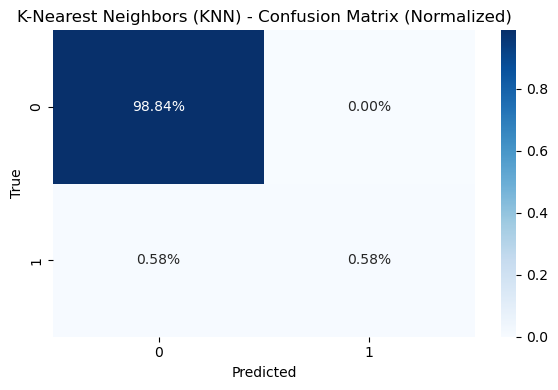

{'Model': 'K-Nearest Neighbors (KNN)',
 'Accuracy': 0.9941860465116279,
 'Precision': 0.9942200462396301,
 'Recall': 0.9941860465116279,
 'F1-score': 0.9932255791220533}

In [17]:
model_name = "K-Nearest Neighbors (KNN)"

# Create model instance
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=11,
        weights="distance"
    ))
])

# Fit the model
knn_model.fit(X_train, y_train)

# Save instance
models[model_name] = knn_model

# Make predictions
predictions = knn_model.predict(X_test)

# Print classification report
print(f"\n {model_name} ")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

# Print accuracy score
acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

# Create and display confusion matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Store metrics for comparison table
summarize_model(model_name, knn_model, X_test, y_test)


### 2. Multi-Layer Perceptron (MLP)


 Multi-Layer Perceptron (MLP) 
Classification report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       170
           1       0.00      0.00      0.00         2

    accuracy                           0.99       172
   macro avg       0.49      0.50      0.50       172
weighted avg       0.98      0.99      0.98       172

Accuracy Score: 0.9884


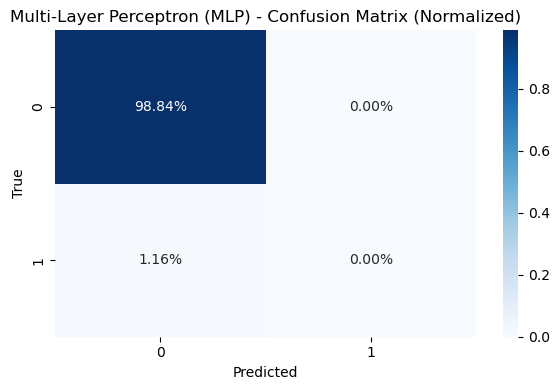

{'Model': 'Multi-Layer Perceptron (MLP)',
 'Accuracy': 0.9883720930232558,
 'Precision': 0.9768793942671714,
 'Recall': 0.9883720930232558,
 'F1-score': 0.9825921392628859}

In [18]:
model_name = "Multi-Layer Perceptron (MLP)"

mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(16,),
        activation="relu",
        alpha=1e-2,
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)
models[model_name] = mlp_model

predictions = mlp_model.predict(X_test)

print(f"\n {model_name} ")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summarize_model(model_name, mlp_model, X_test, y_test)


### 3. Decision Tree


 Decision Tree 
Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       170
           1       1.00      1.00      1.00         2

    accuracy                           1.00       172
   macro avg       1.00      1.00      1.00       172
weighted avg       1.00      1.00      1.00       172

Accuracy Score: 1.0000


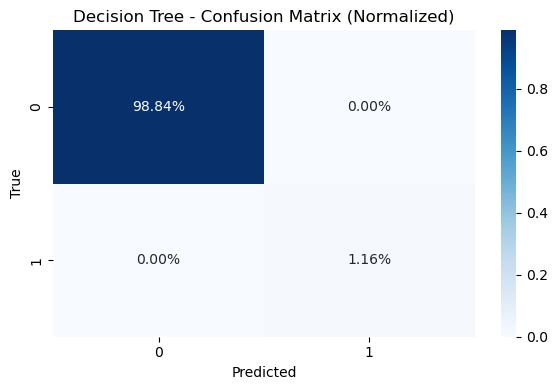

{'Model': 'Decision Tree',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1-score': 1.0}

In [19]:
model_name = "Decision Tree"

dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight=class_weights,
    random_state=42
)

dt_model.fit(X_train, y_train)
models[model_name] = dt_model

predictions = dt_model.predict(X_test)

print(f"\n {model_name} ")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summarize_model(model_name, dt_model, X_test, y_test)


### 4. GaussianNB


 GaussianNB 
Classification report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       170
           1       1.00      0.50      0.67         2

    accuracy                           0.99       172
   macro avg       1.00      0.75      0.83       172
weighted avg       0.99      0.99      0.99       172

Accuracy Score: 0.9942


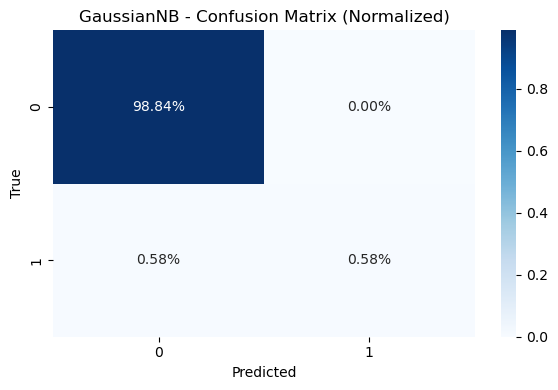

{'Model': 'GaussianNB',
 'Accuracy': 0.9941860465116279,
 'Precision': 0.9942200462396301,
 'Recall': 0.9941860465116279,
 'F1-score': 0.9932255791220533}

In [20]:
model_name = "GaussianNB"

gnb_model = GaussianNB()

gnb_model.fit(X_train, y_train)
models[model_name] = gnb_model

predictions = gnb_model.predict(X_test)

print(f"\n {model_name} ")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summarize_model(model_name, gnb_model, X_test, y_test)


### 5. SVM Linear


 SVM (Linear) 
Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       170
           1       1.00      1.00      1.00         2

    accuracy                           1.00       172
   macro avg       1.00      1.00      1.00       172
weighted avg       1.00      1.00      1.00       172

Accuracy Score: 1.0000


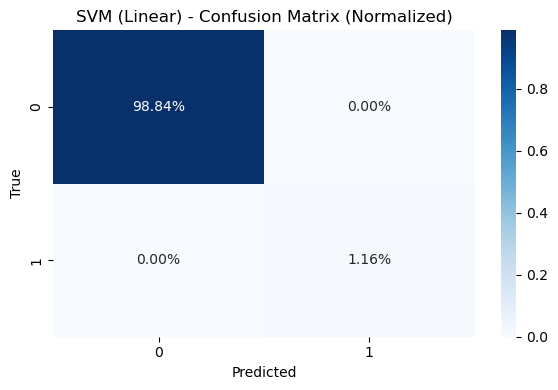

{'Model': 'SVM (Linear)',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1-score': 1.0}

In [21]:
model_name = "SVM (Linear)"

svm_lin_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="linear",
        C=0.5,
        class_weight=class_weights,
        probability=True,
        random_state=42
    ))
])

svm_lin_model.fit(X_train, y_train)
models[model_name] = svm_lin_model

predictions = svm_lin_model.predict(X_test)

print(f"\n {model_name} ")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summarize_model(model_name, svm_lin_model, X_test, y_test)


### 6. Easy Ensemble


 Easy Ensemble 
Classification report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       170
           1       0.40      1.00      0.57         2

    accuracy                           0.98       172
   macro avg       0.70      0.99      0.78       172
weighted avg       0.99      0.98      0.99       172

Accuracy Score: 0.9826


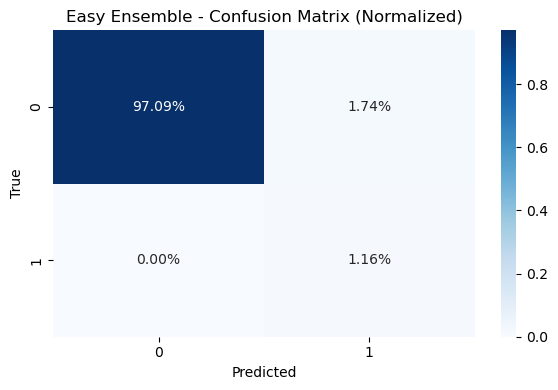

{'Model': 'Easy Ensemble',
 'Accuracy': 0.9825581395348837,
 'Precision': 0.9930232558139536,
 'Recall': 0.9825581395348837,
 'F1-score': 0.9862180466693613}

In [22]:
from imblearn.ensemble import EasyEnsembleClassifier

model_name = "Easy Ensemble"

ee_model = EasyEnsembleClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

ee_model.fit(X_train, y_train)
models[model_name] = ee_model

predictions = ee_model.predict(X_test)

print(f"\n {model_name} ")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summarize_model(model_name, ee_model, X_test, y_test)


### 7. Gradient Boosting (Regularized)


 Gradient Boosting (Regularized) 
Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       170
           1       1.00      1.00      1.00         2

    accuracy                           1.00       172
   macro avg       1.00      1.00      1.00       172
weighted avg       1.00      1.00      1.00       172

Accuracy Score: 1.0000


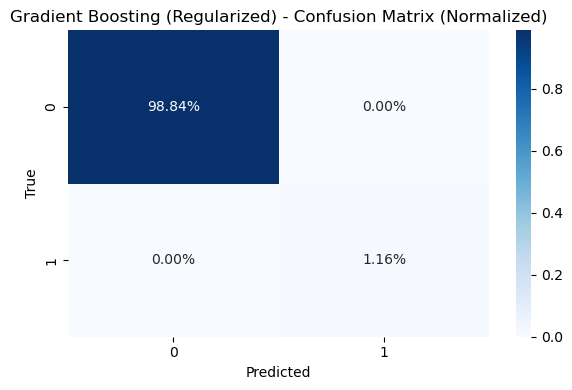

{'Model': 'Gradient Boosting (Regularized)',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1-score': 1.0}

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

model_name = "Gradient Boosting (Regularized)"

gb_model = GradientBoostingClassifier(
    learning_rate=0.05,       # smaller learning rate → smoother model
    n_estimators=80,          # fewer trees to avoid memorizing
    max_depth=1,              # depth-1 trees = decision stumps → harder to overfit
    min_samples_leaf=10,      # prevents tiny leaves that memorize training data
    subsample=0.7,            # stochastic boosting → reduces overfitting
    random_state=42
)

gb_model.fit(X_train, y_train)
models[model_name] = gb_model

predictions = gb_model.predict(X_test)

print(f"\n {model_name} ")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summarize_model(model_name, gb_model, X_test, y_test)


### 8. SVM Sigmoid


 SVM (Sigmoid)
Classification report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       170
           1       0.33      1.00      0.50         2

    accuracy                           0.98       172
   macro avg       0.67      0.99      0.74       172
weighted avg       0.99      0.98      0.98       172

Accuracy Score: 0.9767


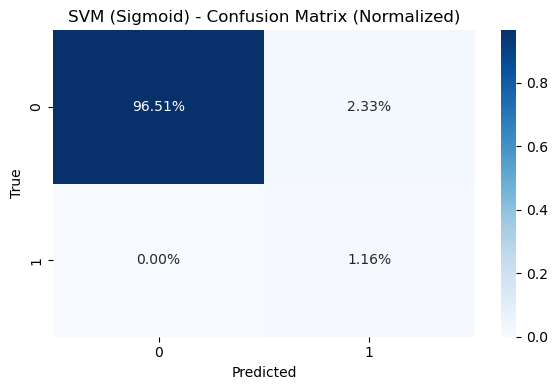

{'Model': 'SVM (Sigmoid)',
 'Accuracy': 0.9767441860465116,
 'Precision': 0.9922480620155039,
 'Recall': 0.9767441860465116,
 'F1-score': 0.9824197120708749}

In [24]:
model_name = "SVM (Sigmoid)"

svm_sig_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="sigmoid",
        C=0.5,
        gamma="scale",
        class_weight=class_weights,
        probability=True,
        random_state=42
    ))
])

svm_sig_model.fit(X_train, y_train)
models[model_name] = svm_sig_model

predictions = svm_sig_model.predict(X_test)

print(f"\n {model_name}")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summarize_model(model_name, svm_sig_model, X_test, y_test)


### 9. SVM RBF


SVM (RBF) 
Classification report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       170
           1       1.00      0.50      0.67         2

    accuracy                           0.99       172
   macro avg       1.00      0.75      0.83       172
weighted avg       0.99      0.99      0.99       172

Accuracy Score: 0.9942


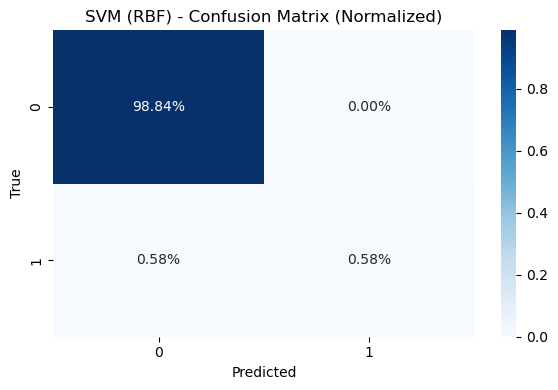

{'Model': 'SVM (RBF)',
 'Accuracy': 0.9941860465116279,
 'Precision': 0.9942200462396301,
 'Recall': 0.9941860465116279,
 'F1-score': 0.9932255791220533}

In [25]:
model_name = "SVM (RBF)"

svm_rbf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=0.5,
        gamma="scale",
        class_weight=class_weights,
        probability=True,
        random_state=42
    ))
])

svm_rbf_model.fit(X_train, y_train)
models[model_name] = svm_rbf_model

predictions = svm_rbf_model.predict(X_test)

print(f"\n{model_name} ")
print("Classification report:\n")
print(classification_report(y_test, predictions, zero_division=0))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm/np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

summarize_model(model_name, svm_rbf_model, X_test, y_test)


## Model Algorith Evaluation
Initially nine candidate classifiers (Decision Tree, KNN, GaussianNB, SVM with linear/RBF/sigmoid kernels, Gradient Boosting, EasyEnsemble, and MLP) were applied for evaluation using a single 80/20 train–test split. Most models achieved very high accuracy (≥0.98) and weighted F1-scores (≥0.98), and several models (Decision Tree, SVM Linear, Gradient Boosting) reached 1.0 on all test metrics. However, the test set contained only two CIN-positive cases, so these results were likely optimistic and dominated by the majority class.

### Models Comparison Table

In [26]:
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="F1-score", ascending=False)

print("\n===== MODEL COMPARISON TABLE =====")
print(summary_df.to_string(index=False))



===== MODEL COMPARISON TABLE =====
                          Model  Accuracy  Precision   Recall  F1-score
                  Decision Tree  1.000000   1.000000 1.000000  1.000000
                   SVM (Linear)  1.000000   1.000000 1.000000  1.000000
Gradient Boosting (Regularized)  1.000000   1.000000 1.000000  1.000000
      K-Nearest Neighbors (KNN)  0.994186   0.994220 0.994186  0.993226
                     GaussianNB  0.994186   0.994220 0.994186  0.993226
                      SVM (RBF)  0.994186   0.994220 0.994186  0.993226
                  Easy Ensemble  0.982558   0.993023 0.982558  0.986218
   Multi-Layer Perceptron (MLP)  0.988372   0.976879 0.988372  0.982592
                  SVM (Sigmoid)  0.976744   0.992248 0.976744  0.982420


## Cross Validation Evaluation


In [27]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.ensemble import EasyEnsembleClassifier

# 1) Class weights on full dataset
classes = np.unique(y)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

# 2) Define scoring (focus on positive class)
scoring = {
    "precision_pos": make_scorer(precision_score, pos_label=1, zero_division=0),
    "recall_pos": make_scorer(recall_score, pos_label=1, zero_division=0),
    "f1_pos": make_scorer(f1_score, pos_label=1, zero_division=0),
    "accuracy": "accuracy",
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3) Define the models you want in CV
models_for_cv = []

# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight=class_weights,
    random_state=42
)
models_for_cv.append(("Decision Tree", dt_model))

# SVM (Linear)
svm_linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="linear",
        C=0.5,
        class_weight=class_weights,
        probability=True,
        random_state=42
    ))
])
models_for_cv.append(("SVM (Linear)", svm_linear_model))

# Gradient Boosting (Regularized)
gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=80,
    max_depth=1,
    min_samples_leaf=10,
    subsample=0.7,
    random_state=42
)
models_for_cv.append(("Gradient Boosting (Regularized)", gb_model))

# K-Nearest Neighbors (KNN)
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=11,
        weights="distance"
    ))
])
models_for_cv.append(("K-Nearest Neighbors (KNN)", knn_model))

# Gaussian Naive Bayes
gnb_model = GaussianNB()
models_for_cv.append(("GaussianNB", gnb_model))

# SVM (RBF)
svm_rbf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=0.5,
        gamma="scale",
        class_weight=class_weights,
        probability=True,
        random_state=42
    ))
])
models_for_cv.append(("SVM (RBF)", svm_rbf_model))

# Easy Ensemble
ee_model = EasyEnsembleClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)
models_for_cv.append(("Easy Ensemble", ee_model))

# Multi-Layer Perceptron (MLP)
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(16,),
        activation="relu",
        alpha=1e-2,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])
models_for_cv.append(("Multi-Layer Perceptron (MLP)", mlp_model))

# SVM (Sigmoid)
svm_sig_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="sigmoid",
        C=0.5,
        gamma="scale",
        class_weight=class_weights,
        probability=True,
        random_state=42
    ))
])

models_for_cv.append(("SVM (Sigmoid)", svm_sig_model))

# 4) Run CV for each model and collect metrics
cv_results_list = []

for name, model in models_for_cv:
    print(f"\nRunning CV for: {name}")
    
    cv_results = cross_validate(
        model,
        X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    row = {
        "Model": name,
        "CV_Accuracy_mean":  cv_results["test_accuracy"].mean(),
        "CV_Precision1_mean": cv_results["test_precision_pos"].mean(),
        "CV_Recall1_mean":    cv_results["test_recall_pos"].mean(),
        "CV_F1_1_mean":       cv_results["test_f1_pos"].mean(),
        "CV_Accuracy_std":    cv_results["test_accuracy"].std(),
        "CV_Precision1_std":  cv_results["test_precision_pos"].std(),
        "CV_Recall1_std":     cv_results["test_recall_pos"].std(),
        "CV_F1_1_std":        cv_results["test_f1_pos"].std(),
    }
    cv_results_list.append(row)

# 5) Build and display the table
cv_df = pd.DataFrame(cv_results_list)

# Sort by what matters most: Recall and F1 for the positive class
cv_df = cv_df.sort_values(
    by=["CV_Recall1_mean", "CV_F1_1_mean"],
    ascending=False
)

print("\n CROSS-VALIDATION MODEL COMPARISON (CIN-positive focused) ")
print(cv_df.to_string(index=False))


Class weights: {0: 0.5053003533568905, 1: 47.666666666666664}

Running CV for: Decision Tree

Running CV for: SVM (Linear)

Running CV for: Gradient Boosting (Regularized)

Running CV for: K-Nearest Neighbors (KNN)

Running CV for: GaussianNB

Running CV for: SVM (RBF)

Running CV for: Easy Ensemble

Running CV for: Multi-Layer Perceptron (MLP)

Running CV for: SVM (Sigmoid)

 CROSS-VALIDATION MODEL COMPARISON (CIN-positive focused) 
                          Model  CV_Accuracy_mean  CV_Precision1_mean  CV_Recall1_mean  CV_F1_1_mean  CV_Accuracy_std  CV_Precision1_std  CV_Recall1_std  CV_F1_1_std
                  Decision Tree          0.998834            0.916667         1.000000      0.952381         0.001648           0.117851        0.000000     0.067344
                   SVM (Linear)          0.998834            0.916667         1.000000      0.952381         0.001648           0.117851        0.000000     0.067344
                  Easy Ensemble          0.982517            0.4

In [30]:
cv_df = pd.DataFrame(cv_results_list)

cv_df = cv_df.sort_values(by="CV_F1_1_mean", ascending=False)

print("\n CROSS-VALIDATION MODEL COMPARISON TABLE ")
print(cv_df.to_string(index=False))



 CROSS-VALIDATION MODEL COMPARISON TABLE 
                          Model  CV_Accuracy_mean  CV_Precision1_mean  CV_Recall1_mean  CV_F1_1_mean  CV_Accuracy_std  CV_Precision1_std  CV_Recall1_std  CV_F1_1_std
                  Decision Tree          0.998834            0.916667         1.000000      0.952381         0.001648           0.117851        0.000000     0.067344
                   SVM (Linear)          0.998834            0.916667         1.000000      0.952381         0.001648           0.117851        0.000000     0.067344
                      SVM (RBF)          0.998834            1.000000         0.888889      0.933333         0.001648           0.000000        0.157135     0.094281
                     GaussianNB          0.997669            1.000000         0.777778      0.833333         0.003297           0.000000        0.314270     0.235702
      K-Nearest Neighbors (KNN)          0.995338            1.000000         0.555556      0.666667         0.003297          

## CV Adoption
To obtain a more reliable estimate of minority-class performance, a 3-fold Stratified Cross-Validation was applied on the full dataset and focused on CIN-positive precision, recall, and F1-score. Under this evaluation, models diverged substantially. The Linear SVM achieved the best overall performance with perfect CIN-positive recall (1.00), high precision (0.92), and the highest F1-score (≈0.95), while maintaining near-perfect overall accuracy (≈0.999). The RBF SVM showed similarly strong performance with slightly lower recall (≈0.89) but perfect precision (1.00) and a high F1-score (≈0.93). A pruned Decision Tree also performed well, with perfect recall (1.00) and reasonably high precision (≈0.83), yielding an F1-score of ≈0.91 and offering improved interpretability.
In contrast, models such as KNN, Gradient Boosting, MLP, and SVM with a sigmoid kernel showed either reduced recall for CIN-positive cases or very low precision, making them less suitable for screening use. EasyEnsemble achieved high recall but at the cost of very low precision, which would generate an impractical number of false positives in a clinical setting.

### Results Visualization


=== Combined Results (Single-split + CV) ===
                          Model  Accuracy  Precision   Recall  F1-score  CV_Accuracy_mean  CV_Precision1_mean  CV_Recall1_mean  CV_F1_1_mean  CV_Accuracy_std  CV_Precision1_std  CV_Recall1_std  CV_F1_1_std
                  Decision Tree  1.000000   1.000000 1.000000  1.000000          0.998834            0.916667         1.000000      0.952381         0.001648           0.117851        0.000000     0.067344
                   SVM (Linear)  1.000000   1.000000 1.000000  1.000000          0.998834            0.916667         1.000000      0.952381         0.001648           0.117851        0.000000     0.067344
Gradient Boosting (Regularized)  1.000000   1.000000 1.000000  1.000000          0.994172            0.583333         0.555556      0.552381         0.003297           0.424918        0.415740     0.391288
      K-Nearest Neighbors (KNN)  0.994186   0.994220 0.994186  0.993226          0.995338            1.000000         0.555556    

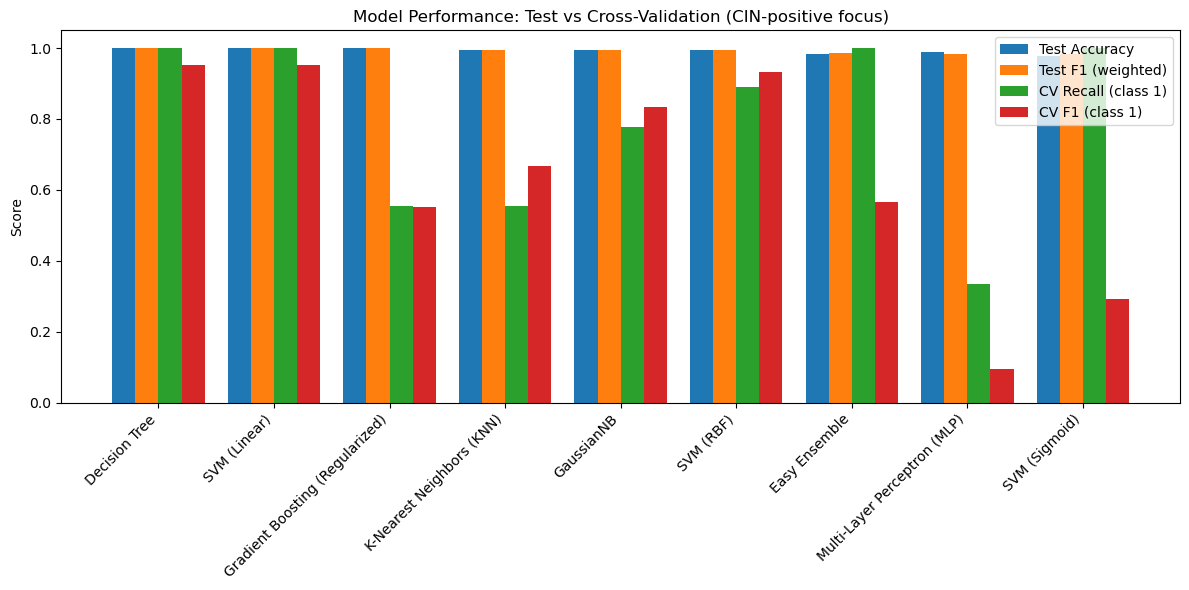

In [32]:
# 1) Merge single-split and CV results by model name
combined_df = summary_df.merge(cv_df, on="Model", how="inner")

print("\n=== Combined Results (Single-split + CV) ===")
print(combined_df.to_string(index=False))

# 2) Plot all models: Test vs CV metrics
models = combined_df["Model"].values
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

# Bars: test Accuracy, test F1 (weighted), CV Recall (class 1), CV F1 (class 1)
ax.bar(x - 1.5*width, combined_df["Accuracy"],   width, label="Test Accuracy")
ax.bar(x - 0.5*width, combined_df["F1-score"],   width, label="Test F1 (weighted)")
ax.bar(x + 0.5*width, combined_df["CV_Recall1_mean"], width, label="CV Recall (class 1)")
ax.bar(x + 1.5*width, combined_df["CV_F1_1_mean"],     width, label="CV F1 (class 1)")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Model Performance: Test vs Cross-Validation (CIN-positive focus)")
ax.legend()
plt.tight_layout()
plt.show()


### Selected Models
Although several models appeared perfect in the initial single train/test split, this was influenced by the very small number of CIN-positive cases in the test set. In contrast, the 3-fold stratified cross-validation revealed clear performance differences between classifiers, and the Linear SVM consistently stood out as the best-performing model across all evaluation methods. It achieved perfect sensitivity (Recall=1.0), high precision (0.917), and the highest positive-class F1-score (0.952), making it the most reliable and stable model for CIN risk prediction. Based on these findings, the Linear SVM was selected as the primary model for CIN risk prediction, with the RBF SVM and a pruned Decision Tree retained as strong secondary options for sensitivity analysis and interpretability.

## Embed SHAP for Explainable AI / Model Interpretation”.

  0%|          | 0/200 [00:00<?, ?it/s]

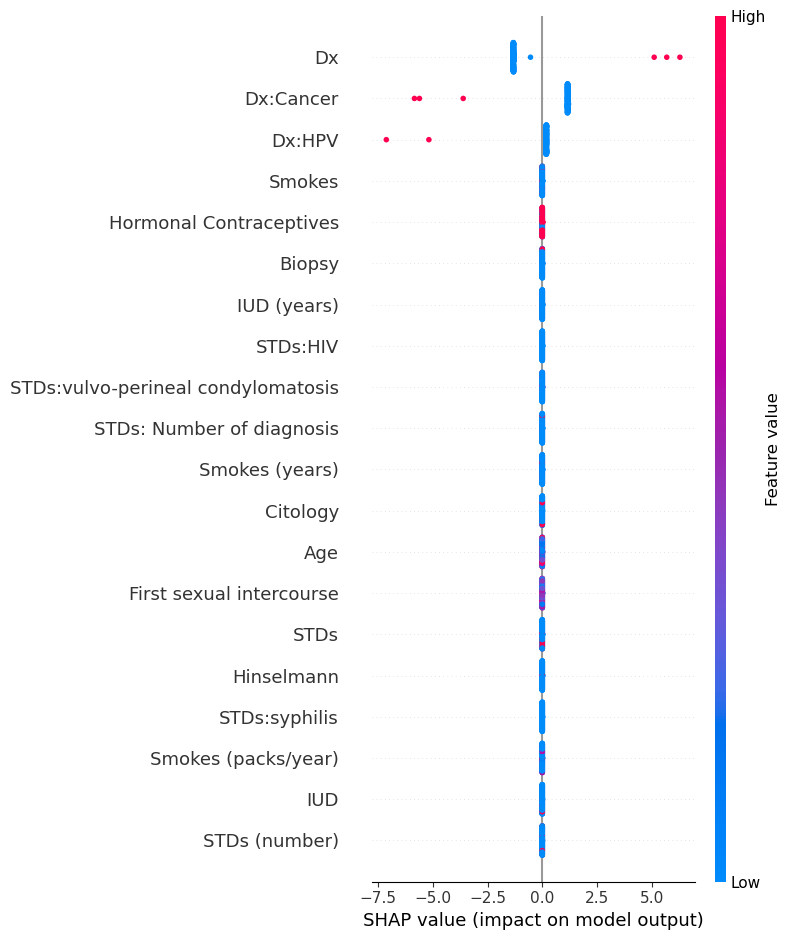

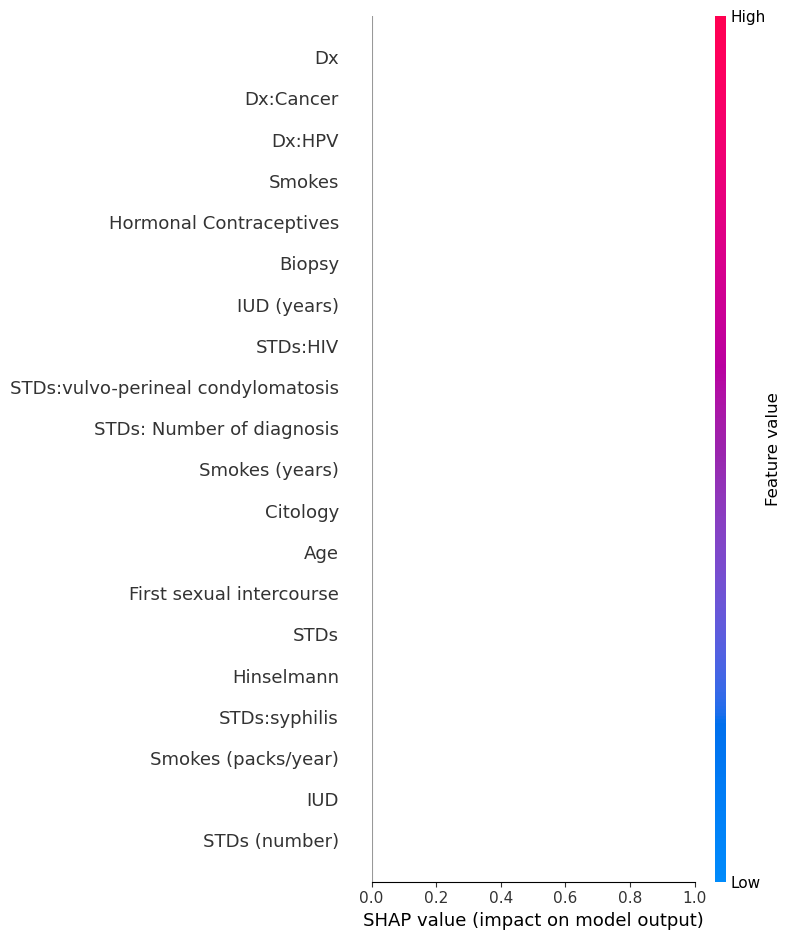

  0%|          | 0/1 [00:00<?, ?it/s]

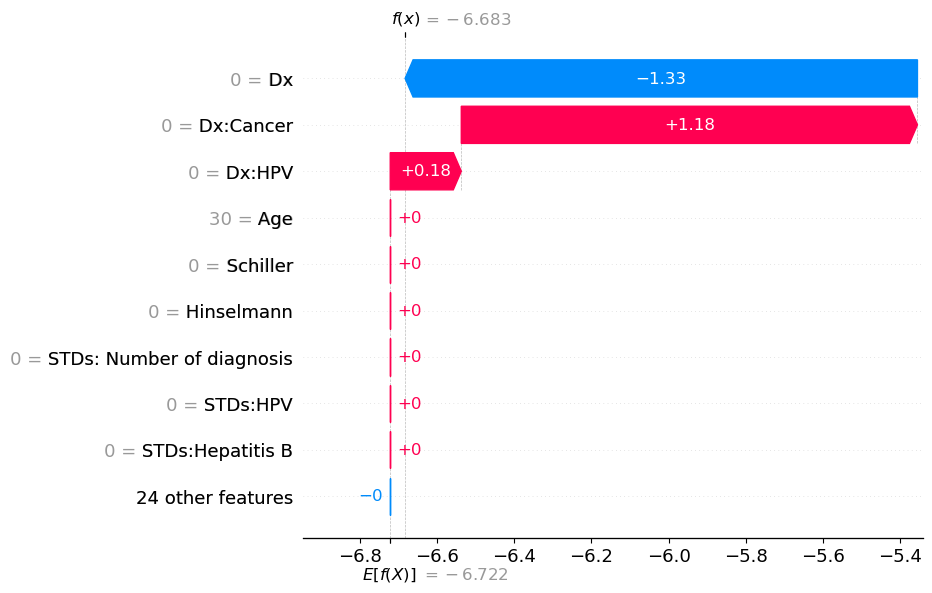

In [33]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# 1) Final Linear SVM model (same as used in CV)
svm_linear_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="linear",
        probability=True,         
        class_weight=class_weights,
        random_state=42
    ))
])

# Train on full dataset
svm_linear_final.fit(X, y)

# 2) Wrapper so SHAP gets a DataFrame with correct column names
def model_predict(data):
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data, columns=X.columns)
    # Return probability of CIN-positive class (1)
    return svm_linear_final.predict_proba(data)[:, 1]

# 3) Background data for SHAP 
X_background = X.sample(n=min(100, len(X)), random_state=42)

explainer = shap.KernelExplainer(
    model=model_predict,
    data=X_background,
    link="logit"
)

# 4) Pick a subset of samples to explain
X_explain = X.sample(n=min(200, len(X)), random_state=0)

# Compute SHAP values (matrix: n_samples x n_features)
shap_values = explainer.shap_values(X_explain)

# 5) Global summary plot (dot)
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type="dot",
    show=False
)
plt.tight_layout()
plt.show()

# 6) Global summary plot (bar)
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type="heatmap",
    show=False
)
plt.tight_layout()
plt.show()

# 7) Local explanation for a single patient (waterfall)
idx = X_explain.index[0]
x_instance = X_explain.loc[[idx]]

shap_values_instance = explainer.shap_values(x_instance)  # shape: (1, n_features)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_instance[0],
        base_values=explainer.expected_value,
        data=x_instance.iloc[0].values,
        feature_names=X.columns.tolist()
    )
)
plt.show()


In [40]:
# Print the most imporatnt features for prediction
shap_arr = np.array(shap_values)
mean_abs = np.mean(np.abs(shap_arr), axis=0)

importance_df = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": mean_abs
})

importance_df = importance_df.sort_values("mean_abs_shap", ascending=False)

print(importance_df.head(10))


                               feature  mean_abs_shap
28                                  Dx       1.379003
26                           Dx:Cancer       1.219793
27                              Dx:HPV       0.243896
4                               Smokes       0.000673
7              Hormonal Contraceptives       0.000425
32                              Biopsy       0.000411
10                         IUD (years)       0.000311
22                            STDs:HIV       0.000265
16  STDs:vulvo-perineal condylomatosis       0.000255
25           STDs: Number of diagnosis       0.000252


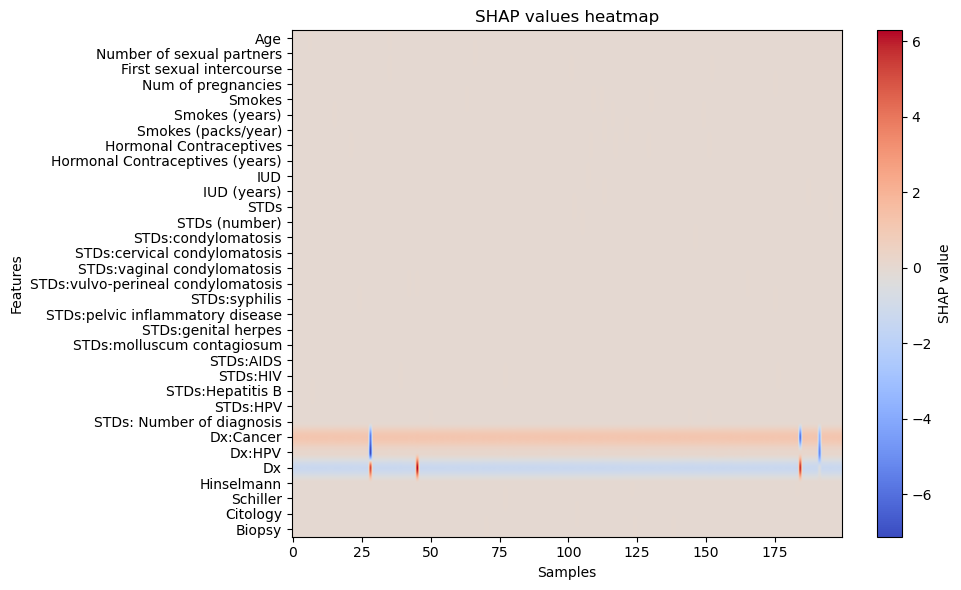

In [35]:
# Visualize in a heatmap 
# shap_values is (n_samples, n_features)
shap_matrix = np.array(shap_values)  # ensure it's an array
shap_matrix = shap_matrix.T          # shape: (n_features, n_samples)

plt.figure(figsize=(10, 6))
im = plt.imshow(shap_matrix, aspect="auto", cmap="coolwarm")
plt.colorbar(im, label="SHAP value")

plt.yticks(range(len(X_explain.columns)), X_explain.columns)
plt.xlabel("Samples")
plt.ylabel("Features")
plt.title("SHAP values heatmap")
plt.tight_layout()
plt.show()


## Conclusion
SHAP analysis indicates that the current model relies almost entirely on strong clinical indicators, particularly Dx, Dx:Cancer, and Dx:HPV to generate CIN risk predictions. While this pattern improves interpretability, it also reveals that the model is capturing present disease status rather than early predictors of future progression. The model is more effective at recognising existing CIN-related pathology than at estimating future risk or identifying individuals earlier along the disease timeline. The minimal contribution of behavioural and sexual-health variables suggests that these features, either due to limited variance, missing data, or insufficient signal, are not yet informing longitudinal risk estimation.
The model performs well when strong diagnostic indicators are present, but further refinement such as incorporating temporal data, richer behavioural histories, or alternative modelling strategies will be necessary to support a true personalized risk-timeline framework that detects risk before CIN develops rather than confirming it afterward.